# 실험 중간 확인이 결론에 미치는 영향

**질문**: A/B 테스트를 매일 확인하면 잘못된 결론에 도달할 확률이
얼마나 오르는가?

**결론**: 두 그룹에 실제 차이가 없는 실험에서, 30일간 매일 확인하면
26.2%가 "유의한 차이"를 관측한다. 1회만 확인할 때(3.9%)의 약 7배다.

대응 방법은 [02_sequential](02_sequential.ipynb)에서 다룬다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abtest_lab.simulation import peeking_sim
from abtest_lab.testing import ztest_p

## 1. 무엇을 재는가

두 그룹의 진짜 전환율을 12%로 동일하게 두고, 하루 그룹당 200명씩
데이터를 누적하며 매일 검정한다.

실제 차이가 없으므로 "유의하다"고 판정된 것은 전부 위양성이다.
한 번이라도 유의해진 실험의 비율을 센다.

In [3]:
peeks = [1, 3, 7, 14, 30]
rates = [peeking_sim(k) for k in peeks]

pd.DataFrame({
    "확인 횟수": peeks,
    "위양성률": [f"{r:.1%}" for r in rates],
})

,확인 횟수,위양성률
0,1,3.9%
1,3,10.7%
2,7,16.0%
3,14,22.8%
4,30,26.2%


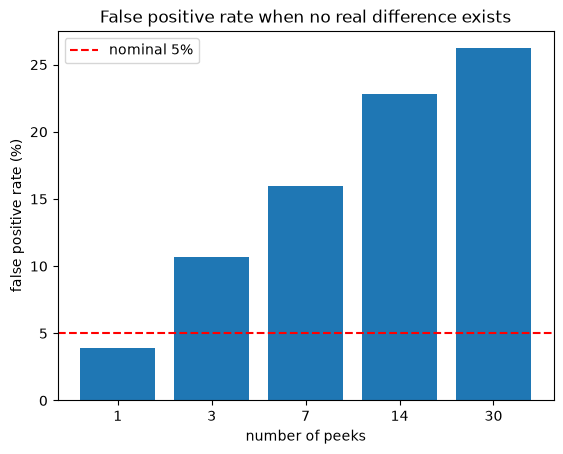

In [4]:
plt.bar([str(k) for k in peeks], [r * 100 for r in rates])
plt.axhline(5, color="red", linestyle="--", label="nominal 5%")
plt.xlabel("number of peeks")
plt.ylabel("false positive rate (%)")
plt.title("False positive rate when no real difference exists")
plt.legend()
plt.show()

## 2. 해석

1회 확인일 때 3.9%가 나온 것은 유의수준 0.05의 정의 그대로다.
시뮬레이션이 제대로 작동한다는 확인이기도 하다.

30회 확인 시 26.2%. 진짜 차이가 없는 실험에서 4번 중 1번은
"유의한 차이"를 보게 된다는 뜻이다.

증가 폭은 점점 줄어든다. 1→3회에서 6.8%p 오르지만 14→30회에서는
3.4%p에 그친다. 데이터가 누적되므로 어제 p값과 오늘 p값이 크게
다르지 않기 때문이다. 뒤로 갈수록 하루치가 전체에서 차지하는
비중이 작아져 p값이 잘 움직이지 않는다.

바꿔 말하면 **엿보기가 가장 위험한 구간은 실험 초반**이다.
표본이 적어 p값이 크게 출렁인다.

## 3. p값은 어떻게 움직이는가

진짜 차이가 0인 실험 네 개의 p값 궤적을 그린다.
시드만 다르고 조건은 모두 같다.

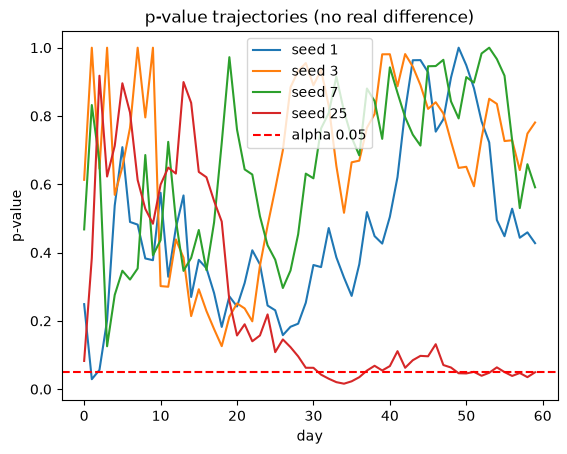

In [5]:
for s in [1, 3, 7, 25]:
    rng = np.random.default_rng(seed=s)
    cum_a = cum_b = cum_n = 0
    ps = []

    for day in range(60):
        cum_a += rng.binomial(200, 0.12)
        cum_b += rng.binomial(200, 0.12)
        cum_n += 200
        z, p = ztest_p(cum_n, cum_n, cum_a, cum_b)
        ps.append(p)

    plt.plot(ps, label=f"seed {s}")

plt.axhline(0.05, color="red", linestyle="--", label="alpha 0.05")
plt.xlabel("day")
plt.ylabel("p-value")
plt.title("p-value trajectories (no real difference)")
plt.legend()
plt.show()

초반에 크게 출렁이다 뒤로 갈수록 잔잔해진다. 앞 절에서 본 증가 폭
패턴이 그림으로 나타난 것이다.

네 실험 모두 두 그룹에 실제 차이가 없다. 그런데 어떤 선은 한 번도
기준선 아래로 내려가지 않고, 어떤 선은 내려갔다 올라온다.
내려간 날 확인한 사람은 실험을 멈추고 "이겼다"고 보고했을 것이다.
며칠 더 뒀으면 다시 올라갔을 텐데.

**같은 조건의 실험인데 언제 봤느냐로 결론이 갈린다.**

## 4. 실무 대응

**① 기간을 미리 정하고 지킨다**

필요 표본을 계산해 문서에 적어둔다.

```python
from abtest_lab.power import sample_size
sample_size(p_base=0.12, mde=0.03)   # 2036 (그룹당)
```

"필요 표본 2,036명, 일 트래픽 500명 → 9일 후 판단"처럼 명시해두면
"지금 유의한데요?"라는 압박을 막을 근거가 된다.

**② 모니터링과 판단을 분리한다**

매일 보는 것 자체는 문제가 아니다. 보되 판단하지 않으면 된다.

- 모니터링: 버그, SRM, 지표 폭락 감시 — 매일 필요
- 판단: 승패 결정 — 정해진 시점에 한 번

**③ 순차검정**

정말 중간에 판단해야 한다면 시점마다 유의수준을 나눠 쓴다.
30회 확인 기준으로 위양성률을 0.7%까지 낮출 수 있으며,
검정력 손실은 1%p에 그친다. [02_sequential](02_sequential.ipynb)에서 다룬다.

## 5. 다중검정과의 차이

세그먼트를 여러 개 보는 경우([03_multiple_testing](03_multiple_testing.ipynb))와
구조가 비슷하지만 상승 폭이 다르다.

| | 반복 대상 | 20~30회 시 위양성률 |
|---|---|---|
| 다중검정 | 서로 다른 세그먼트 | 66% |
| 엿보기 | 같은 실험을 반복 확인 | 26% |

다중검정은 매번 독립적인 데이터라 새로운 기회가 주어진다.
엿보기는 데이터가 누적되므로 인접 시점의 p값이 비슷하다.